# *Importing Libraries*

In [2]:
import pandas as pd
import seaborn as sns
import kagglehub as kgh
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt


## Loading Dataset

In [3]:
df = kgh.dataset_load(KaggleDatasetAdapter.PANDAS,
  "laveshjadon/ai-impact-on-students", "ai_student_impact_dataset (1).csv")
df


Using Colab cache for faster access to the 'ai-impact-on-students' dataset.


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [4]:
df.columns


Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

### *Dividing the data into X and Y*

In [5]:
y = df['Post_Semester_GPA']
y

,Post_Semester_GPA
0,2.393
1,3.696
2,3.499
3,4.000
4,3.798
...,...
49995,3.584
49996,3.096
49997,3.605
49998,3.527


In [6]:
x = df.drop(columns=['Post_Semester_GPA','Student_ID'], axis = 1)
x = pd.get_dummies(x,drop_first=True)


## *Dividing the data into train and test*

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
x_train

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score,Major_Category_Business,Major_Category_Humanities,...,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium
39087,3.786,12.59,3,False,6.71,3,2,81.56,False,True,...,False,False,False,False,True,False,True,False,False,True
30893,3.753,1.14,3,False,11.43,3,2,46.05,False,True,...,False,False,False,True,True,False,True,False,True,False
45278,2.931,3.63,4,False,12.46,1,2,70.66,True,False,...,False,False,True,False,False,True,False,False,False,True
16398,3.846,6.10,2,False,19.42,4,6,74.13,False,False,...,False,True,False,False,True,False,True,False,True,False
13653,1.997,14.17,5,False,12.95,6,5,73.33,True,False,...,False,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,3.589,2.19,1,True,10.95,4,4,63.34,False,False,...,False,True,False,False,True,False,False,True,True,False
44732,3.793,2.36,2,False,18.42,3,9,97.35,False,False,...,True,False,False,False,True,False,True,False,True,False
38158,3.804,8.22,1,True,13.26,4,5,86.00,False,True,...,False,False,False,False,True,False,True,False,False,False
860,2.899,16.62,1,False,6.94,7,9,84.80,False,False,...,False,False,False,False,True,False,False,False,False,True


## *Model Building*

### *Linear Regression*

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

*Applying the model to make predictions*

In [10]:
l_lr_train_pred = lr.predict(x_train)
l_lr_test_pred = lr.predict(x_test)

*Prediction on training*

In [11]:
print(l_lr_train_pred)


[3.93128443 3.81343146 3.06622313 ... 3.98794765 3.06683559 2.9023524 ]


*Prediction on testing*

In [12]:
print(l_lr_test_pred)

[2.36649513 3.18687857 3.05441446 ... 3.3973222  3.02531241 3.09532291]


# *Model Performance*

In [13]:
from sklearn.metrics import mean_squared_error, r2_score
lr_train_mse = mean_squared_error(y_train, l_lr_train_pred)
lr_train_r2 = r2_score(y_train, l_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, l_lr_test_pred)
lr_test_r2 = r2_score(y_test, l_lr_test_pred)

In [14]:
print ('LR MSE (train):',lr_train_mse)
print ('LR R2 (train):',lr_train_r2)
print ('LR MSE (test):',lr_test_mse)
print ('LR R2 (test):',lr_test_r2)

LR MSE (train): 0.025596650269733325
LR R2 (train): 0.896266527842357
LR MSE (test): 0.024797888533183987
LR R2 (test): 0.897268613733395


In [15]:
lr_results = pd.DataFrame(['Linear regression',lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'MSE_train', 'R2_train', 'MSE_test', 'R2_test']
lr_results

,Method,MSE_train,R2_train,MSE_test,R2_test
0,Linear regression,0.025597,0.896267,0.024798,0.897269


## **Model Two**
Removing pre_semester_gpa and retraning the model


In [16]:
X2 = df.drop(columns=[
    'Student_ID',
    'Post_Semester_GPA',
    'Pre_Semester_GPA'
])

X2 = pd.get_dummies(X2, drop_first=True)

In [17]:
y = df['Post_Semester_GPA']

*Splitting the Data*


In [18]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

**Train Model 2**

In [19]:
from sklearn.linear_model import LinearRegression

lr2 = LinearRegression()

lr2.fit(X2_train, y_train)

LinearRegression()

Predictions

In [20]:
lr2_train_pred = lr2.predict(X2_train)
lr2_test_pred = lr2.predict(X2_test)

Evaluation


In [21]:
from sklearn.metrics import mean_squared_error, r2_score

lr2_train_mse = mean_squared_error(y_train, lr2_train_pred)
lr2_train_r2 = r2_score(y_train, lr2_train_pred)

lr2_test_mse = mean_squared_error(y_test, lr2_test_pred)
lr2_test_r2 = r2_score(y_test, lr2_test_pred)

print("Training MSE:", lr2_train_mse)
print("Training R²:", lr2_train_r2)

print("Testing MSE:", lr2_test_mse)
print("Testing R²:", lr2_test_r2)

Training MSE: 0.23152301575761017
Training R²: 0.0617254189176446
Testing MSE: 0.22589195730063838
Testing R²: 0.06418669924589226


**MODEL 1**

Actual vs predicted

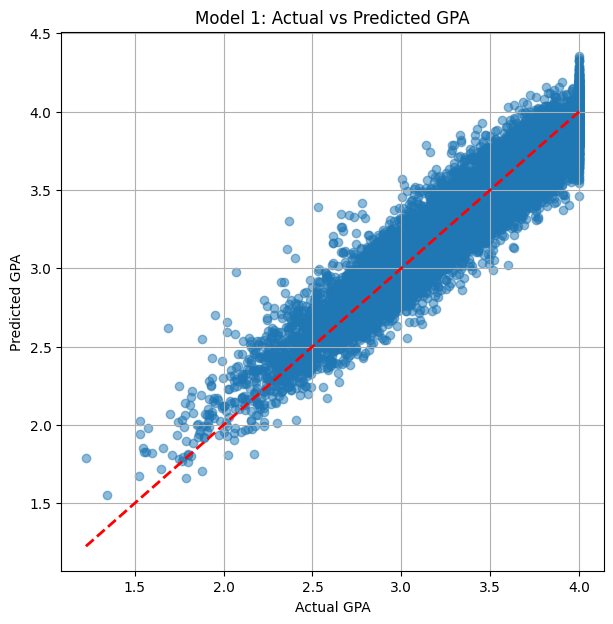

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

# Scatter plot
plt.scatter(y_test, l_lr_test_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Model 1: Actual vs Predicted GPA")

plt.grid(True)
plt.show()

***MODEL 2**

Acutal vs predicted

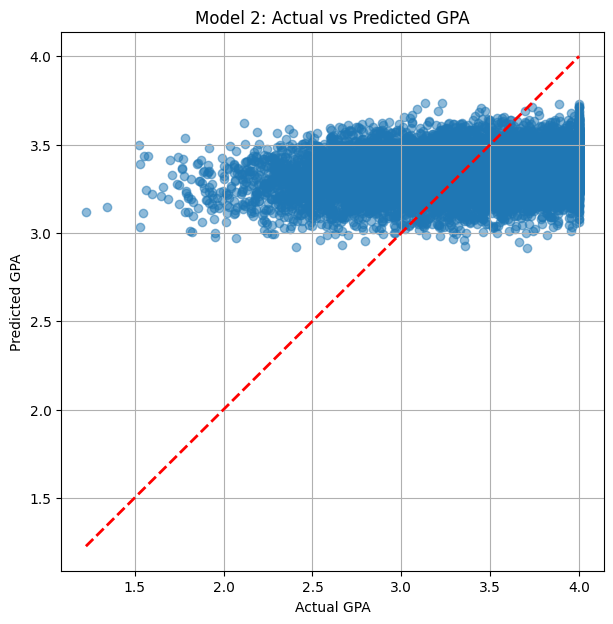

In [23]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, lr2_test_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Model 2: Actual vs Predicted GPA")

plt.grid(True)
plt.show()

Selecting Numeric columns

In [24]:
numeric_df = df.select_dtypes(include=['number'])

Compute the correlation matrix

In [25]:
corr_matrix = numeric_df.corr()

Heatmap

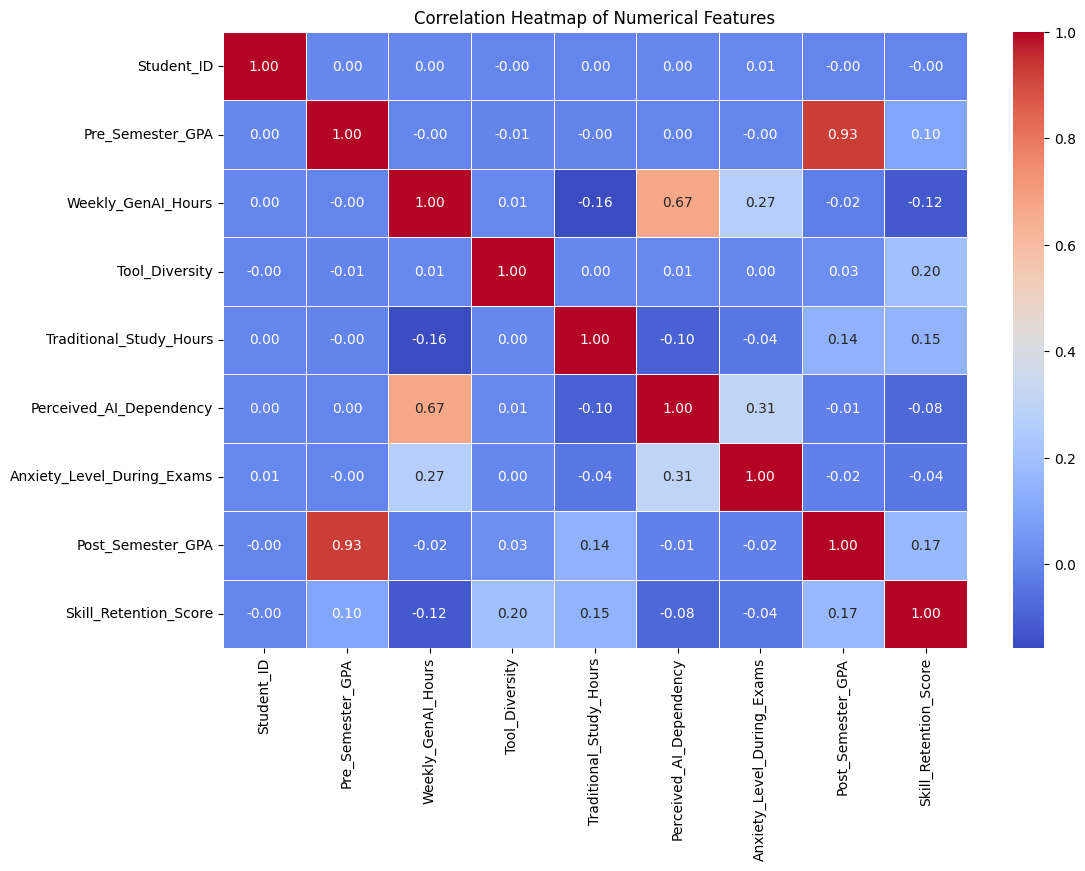

In [26]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()